# Lecture 4 — Class Exercise
## Scatter & Bubble Charts: Gapminder

> **Push to:** `week04/lecture04_exercise.ipynb`

**Rules:**
1. Colour used **sparingly** — one categorical variable, no rainbow
2. If showing all continents, either use accessible palette OR grey all + highlight one
3. `size_max` set when using bubble size
4. Log scale for GDP per capita
5. Insight title

---


In [1]:
import pandas as pd
import plotly.express as px


# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source: Gapminder Foundation (gapminder.org)

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())

Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


In [2]:
# explore

print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB
None
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: ['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']
         year  lifeExp           pop  gdpPercap  iso_num
count  1704.0   1704.0  1.704000e+03     1704.0   1704.0
mean   1979.5     59.5  2.960121e+07     7215.3    

## Task 1 — Scatter: life expectancy change over time

**What to build:** A scatter showing **GDP per capita vs life expectancy** for **two years** (2002 and 2007) to show how both moved — use **colour for year** (just 2 colours), **one continent only**.

Choose any continent except Africa (that was the example). Highlight the change direction.

> 💡 Filter: `df.loc[df['continent'] == 'YOUR_CHOICE']` then filter years


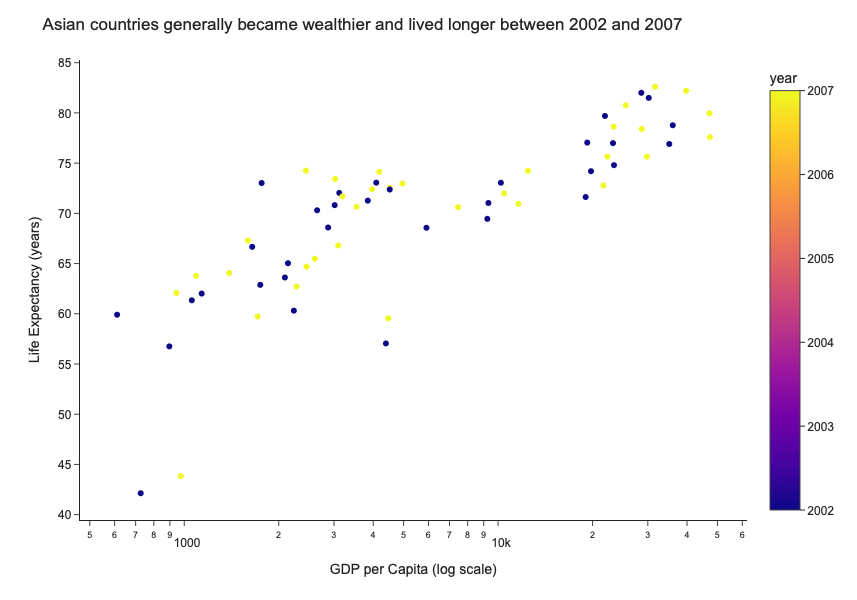

In [3]:
# Task 1
# YOUR CODE HERE
import pandas as pd
import plotly.express as px

# Asia only
asia = df[
    (df['continent'] == 'Asia') &
    (df['year'].isin([2002, 2007]))
]

fig = px.scatter(
    asia,
    x='gdpPercap',
    y='lifeExp',
    color='year',
    hover_name='country',
    color_discrete_map={
        2002: '#BDBDBD',
        2007: '#1f77b4'
    }
)

fig.update_layout(
    title='Asian countries generally became wealthier and lived longer between 2002 and 2007',
    template='simple_white',
    font=dict(family='Arial'),
    xaxis_title='GDP per Capita (log scale)',
    yaxis_title='Life Expectancy (years)',
    height=600
)

# Required: log GDP scale
fig.update_xaxes(type='log')

fig.show()

## Task 2 — Bubble chart: tell a story

**What to build:** A bubble chart (full 2007 dataset, all countries) where:
- x = GDP per capita (log scale)
- y = life expectancy
- size = population
- colour = ONE continent highlighted (your choice), all others grey
- At least one annotation explaining the highlighted group's story

> This is the grey-and-highlight technique applied to a bubble chart.


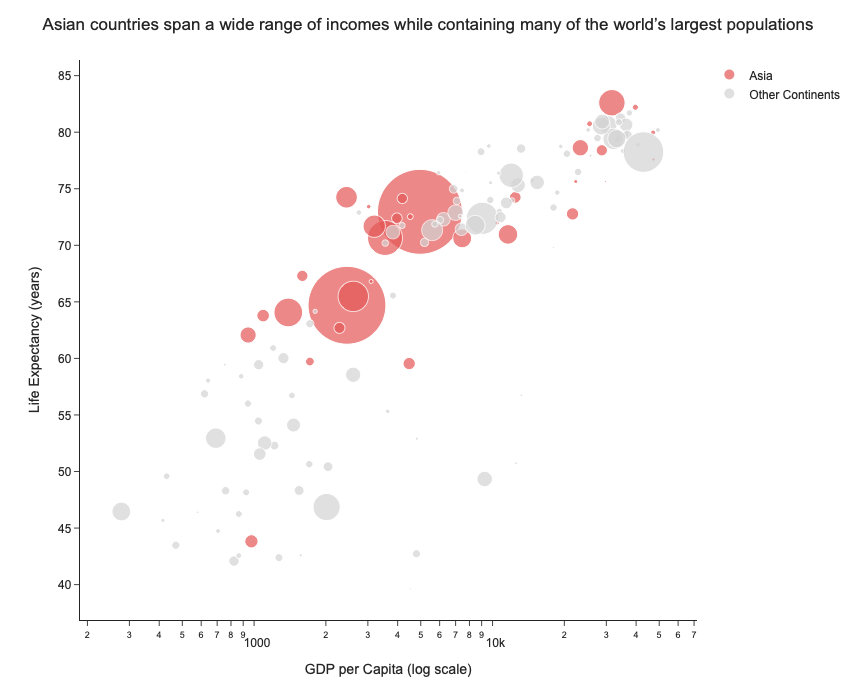

In [4]:
# Task 2
# YOUR CODE HERE
import pandas as pd
import plotly.express as px

# 2007 data only
gap2007 = df[df['year'] == 2007].copy()

# Create highlight group
gap2007['Highlight'] = gap2007['continent'].apply(
    lambda x: 'Asia' if x == 'Asia' else 'Other Continents'
)

fig = px.scatter(
    gap2007,
    x='gdpPercap',
    y='lifeExp',
    size='pop',
    color='Highlight',
    hover_name='country',
    size_max=60,
    color_discrete_map={
        'Asia': '#E45756',
        'Other Continents': '#D3D3D3'
    }
)

fig.update_layout(
    title='Asian countries span a wide range of incomes while containing many of the world’s largest populations',
    template='simple_white',
    font=dict(family='Arial'),
    xaxis_title='GDP per Capita (log scale)',
    yaxis_title='Life Expectancy (years)',
    height=700,
    legend_title=''
)

# Required: log scale
fig.update_xaxes(type='log')

# Annotation
fig.add_annotation(
    x=5000,
    y=78,
    text='Asia includes several highly populated countries<br>with rapidly improving life expectancy',
    showarrow=True,
    arrowhead=2
)

fig.show()